# 第四题正确 Baseline：2 月 NTU 补全 + 完整近三个月风险评价

本 notebook 是第四题的**切题版 baseline**。

---

## 题目要求

题目要求：

```text
以水浊度 NTU 为核心指标，结合超标幅度与异常持续时长，建立水质风险评价体系，
将 2026 年近 3 个月水质划分为：安全、低风险、中风险、高风险，
给出各等级天数占比，并给出 3 月份的具体分类结果。
```

因此第四题主线应该是：

```text
NTU 数据完整化
↓
计算超标幅度
↓
计算异常持续时长
↓
风险等级划分
↓
统计近三个月等级占比
↓
列出 3 月具体分类
```

---

## 本 notebook 的关键修正

### 1. 不再直接跳过 2 月

当前数据中：

```text
2026 年 2 月 NTU 观测值缺失
```

如果直接删除 NTU 缺失值，只会评价 1 月和 3 月，不能严格覆盖“近三个月”。

因此本 notebook 会：

```text
用 NTU 补全模型预测 2 月缺失 NTU
```

然后基于：

```text
1 月和 3 月实测 NTU
+
2 月模型补全 NTU
```

进行完整 1–3 月风险评价。

---

### 2. 风险划分只使用题目要求的两个维度

题目明确说：

```text
结合超标幅度与异常持续时长
```

因此本 notebook 的主判定规则只使用：

```text
max_excess：最大超标幅度
exceed_duration_hours：异常持续时长
```

不再使用：

```text
max_consecutive_exceed_hours
```

连续超标时长可以辅助分析，但不作为风险等级主判定条件。

---

## 风险划分规则

| 等级 | 规则 |
|---|---|
| 安全 | `max_NTU <= 1` |
| 低风险 | `0 < max_excess <= 0.2` 且 `exceed_duration_hours <= 2` |
| 高风险 | `max_excess > 0.5` 或 `exceed_duration_hours >= 6` |
| 中风险 | 有超标，但不满足低风险或高风险 |

---

## 输出目录

```text
outputs/problem4_correct_baseline/
```

核心输出：

```text
problem4_ntu_imputation_model_results.xlsx
problem4_point_level_status.xlsx
problem4_daily_risk_indicators.xlsx
problem4_daily_risk_classification.xlsx
problem4_risk_level_proportion.xlsx
problem4_march_daily_classification.xlsx
problem4_correct_baseline_summary.xlsx
figures/
models/
```


## 1. 导入依赖库

In [12]:
from pathlib import Path
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception as e:
    XGB_AVAILABLE = False
    XGB_IMPORT_ERROR = e

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 260)

print("XGBoost available:", XGB_AVAILABLE)
if not XGB_AVAILABLE:
    print("XGBoost import error:", XGB_IMPORT_ERROR)


XGBoost available: True


## 2. 参数设置

In [13]:
TARGET_COL = "NTU"
OUTPUT_DIR_NAME = "problem4_correct_baseline"

RANDOM_STATE = 42

# 第四题评价窗口
EVAL_START = "2026-01-01"
EVAL_END = "2026-03-31"

# 3 月具体分类输出
MARCH_START = "2026-03-01"
MARCH_END = "2026-03-31"

# 水质硬约束
NTU_THRESHOLD = 1.0

# 低风险阈值：轻微短时超标
LOW_RISK_MAX_EXCESS = 0.2
LOW_RISK_MAX_DURATION_HOURS = 2.0

# 高风险阈值：幅度大或持续时间长
HIGH_RISK_MAX_EXCESS = 0.5
HIGH_RISK_MIN_DURATION_HOURS = 6.0

# 数据时间间隔
RECORD_INTERVAL_HOURS = 2.0

# NTU 补全模型随机验证划分
IMPUTE_TEST_SIZE = 0.20

print("参数设置完成。")


参数设置完成。


## 3. 自动定位 `merged.xlsx`

In [14]:
def locate_merged_file(filename="merged.xlsx"):
    cwd = Path.cwd().resolve()
    candidates = []

    search_roots = [cwd] + list(cwd.parents)

    for root in search_roots:
        candidates.extend([
            root / "data" / filename,
            root / "codes" / "data" / filename,
            root / "2026-Asia-Pacific-cup" / "data" / filename,
            root / "2026-Asia-Pasific-cup" / "data" / filename,
            root / filename,
        ])

    seen = set()
    unique_candidates = []

    for p in candidates:
        p = p.resolve()
        if p not in seen:
            seen.add(p)
            unique_candidates.append(p)

    for p in unique_candidates:
        if p.exists():
            return p

    for p in cwd.rglob(filename):
        return p.resolve()

    for parent in cwd.parents:
        try:
            for p in parent.rglob(filename):
                return p.resolve()
        except Exception:
            pass

    searched = "\n".join(str(p) for p in unique_candidates)
    raise FileNotFoundError(f"未找到 {filename}。已检查路径：\n{searched}")


DATA_PATH = locate_merged_file()
DATA_DIR = DATA_PATH.parent

if DATA_DIR.name == "data":
    PROJECT_DIR = DATA_DIR.parent
else:
    PROJECT_DIR = DATA_DIR

OUTPUT_DIR = PROJECT_DIR / "outputs" / OUTPUT_DIR_NAME
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("当前工作目录：", Path.cwd().resolve())
print("使用数据文件：", DATA_PATH)
print("输出目录：", OUTPUT_DIR)


当前工作目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes
使用数据文件： E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx
输出目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline


## 4. 读取数据并构造时间列

In [15]:
df = pd.read_excel(DATA_PATH)

print("原始数据规模：", df.shape)
print("原始列名：")
print(df.columns.tolist())

if TARGET_COL not in df.columns:
    raise ValueError(f"未找到目标变量 {TARGET_COL}。请检查 merged.xlsx。")


def construct_datetime(data):
    data = data.copy()

    if "DATETIME" in data.columns:
        data["DATETIME"] = pd.to_datetime(data["DATETIME"], errors="coerce")
        return data

    date_candidates = ["DATE", "Date", "date"]
    time_candidates = ["TIME", "Time", "time"]

    date_col = next((c for c in date_candidates if c in data.columns), None)
    time_col = next((c for c in time_candidates if c in data.columns), None)

    if date_col is None or time_col is None:
        raise ValueError("无法构造 DATETIME：需要 DATE 和 TIME 两列，或已有 DATETIME 列。")

    date_text = data[date_col].astype(str).str.split().str[0]
    time_text = data[time_col].astype(str).str.split().str[-1]

    data["DATETIME"] = pd.to_datetime(
        date_text + " " + time_text,
        errors="coerce",
    )

    return data


df = construct_datetime(df)
df = df.dropna(subset=["DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

# 构造运行日：当日 07:00 至次日 05:00 归为同一运行日
df["OP_DATE"] = df["DATETIME"].dt.date
mask_before_7 = df["DATETIME"].dt.hour < 7
df.loc[mask_before_7, "OP_DATE"] = (
    df.loc[mask_before_7, "DATETIME"] - pd.Timedelta(days=1)
).dt.date

df["OP_DATE"] = pd.to_datetime(df["OP_DATE"])

print("时间范围：", df["DATETIME"].min(), "至", df["DATETIME"].max())
display(df[["DATETIME", "OP_DATE", TARGET_COL]].head(15))
display(df[["DATETIME", "OP_DATE", TARGET_COL]].tail(15))


原始数据规模： (5460, 18)
原始列名：
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']
时间范围： 2025-01-01 07:00:00 至 2026-04-01 05:00:00


,DATETIME,OP_DATE,NTU
0,2025-01-01 07:00:00,2025-01-01,0.12
1,2025-01-01 09:00:00,2025-01-01,0.12
2,2025-01-01 11:00:00,2025-01-01,0.12
3,2025-01-01 13:00:00,2025-01-01,0.11
4,2025-01-01 15:00:00,2025-01-01,0.11
5,2025-01-01 17:00:00,2025-01-01,0.11
6,2025-01-01 19:00:00,2025-01-01,0.11
7,2025-01-01 21:00:00,2025-01-01,0.11
8,2025-01-01 23:00:00,2025-01-01,0.12
9,2025-01-02 01:00:00,2025-01-01,0.12


,DATETIME,OP_DATE,NTU
5445,2026-03-31 01:00:00,2026-03-30,0.25
5446,2026-03-31 03:00:00,2026-03-30,0.25
5447,2026-03-31 05:00:00,2026-03-30,0.25
5448,2026-03-31 07:00:00,2026-03-31,0.25
5449,2026-03-31 09:00:00,2026-03-31,0.25
5450,2026-03-31 11:00:00,2026-03-31,0.24
5451,2026-03-31 13:00:00,2026-03-31,0.24
5452,2026-03-31 15:00:00,2026-03-31,0.27
5453,2026-03-31 17:00:00,2026-03-31,0.27
5454,2026-03-31 19:00:00,2026-03-31,0.26


## 5. 基础数值化、泵状态转换与 F/RIDE 处理

In [16]:
def pump_duty_to_count(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s == "":
        return np.nan

    if s.endswith(".0"):
        s = s.replace(".0", "")

    if "+" in s:
        parts = [p.strip() for p in s.split("+") if p.strip() != ""]
        return len(parts)

    if s.isdigit():
        return 1

    return np.nan


if "R/W PUMP DUTY" in df.columns:
    df["R/W PUMP COUNT"] = df["R/W PUMP DUTY"].apply(pump_duty_to_count)

if "T/W PUMP DUTY" in df.columns:
    df["T/W PUMP COUNT"] = df["T/W PUMP DUTY"].apply(pump_duty_to_count)

non_numeric_cols = {
    "DATE", "Date", "date",
    "TIME", "Time", "time",
    "DATETIME", "OP_DATE",
    "REMARKS",
    "R/W PUMP DUTY",
    "T/W PUMP DUTY",
}

for col in df.columns:
    if col not in non_numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "F/RIDE" in df.columns:
    before_missing = int(df["F/RIDE"].isna().sum())
    df["F/RIDE"] = df["F/RIDE"].fillna(0)
    after_missing = int(df["F/RIDE"].isna().sum())
    print(f"F/RIDE 缺失填 0：before={before_missing}, after={after_missing}")

print("数值化处理完成。")


F/RIDE 缺失填 0：before=0, after=0
数值化处理完成。


## 6. 检查 2026 年近三个月 NTU 缺失情况

In [17]:
eval_start = pd.to_datetime(EVAL_START)
eval_end = pd.to_datetime(EVAL_END)

eval_mask = (df["OP_DATE"] >= eval_start) & (df["OP_DATE"] <= eval_end)
eval_raw_df = df.loc[eval_mask].copy().sort_values("DATETIME").reset_index(drop=True)

eval_raw_df["MONTH"] = eval_raw_df["OP_DATE"].dt.to_period("M").astype(str)

missing_month_summary = (
    eval_raw_df
    .groupby("MONTH", as_index=False)
    .agg(
        total_records=("DATETIME", "count"),
        observed_NTU_count=(TARGET_COL, lambda s: int(s.notna().sum())),
        missing_NTU_count=(TARGET_COL, lambda s: int(s.isna().sum())),
        valid_days=("OP_DATE", lambda s: int(pd.Series(s).nunique())),
    )
)

missing_month_summary["missing_rate"] = (
    missing_month_summary["missing_NTU_count"] / missing_month_summary["total_records"]
)

missing_summary_path = OUTPUT_DIR / "problem4_ntu_missing_month_summary.xlsx"
missing_month_summary.to_excel(missing_summary_path, index=False)

print("评价窗口数据规模：", eval_raw_df.shape)
print("NTU 缺失月度审计已保存：", missing_summary_path)
display(missing_month_summary)


评价窗口数据规模： (1080, 23)
NTU 缺失月度审计已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_ntu_missing_month_summary.xlsx


,MONTH,total_records,observed_NTU_count,missing_NTU_count,valid_days,missing_rate
0,2026-01,372,372,0,31,0.0
1,2026-02,336,0,336,28,1.0
2,2026-03,372,372,0,31,0.0


## 7. 构造 NTU 补全模型特征

用于补全 2 月缺失 NTU 的候选特征包括水厂运行变量和水质过程变量。

注意：

```text
NTU 是补全目标，不能作为输入特征。
DATETIME / OP_DATE / REMARKS / 原始泵 duty 字符串不作为输入。
```


In [18]:
candidate_feature_cols = [
    "RIVER LEVEL",
    "R/W PUMP COUNT",
    "R/W FLOW",
    "R/W NTU",
    "R/W CLR",
    "R/W PH",
    "FILT. NTU",
    "C/W WELL LEVEL",
    "PH",
    "CLR",
    "CL2",
    "F/RIDE",
    "ALUM",
    "T/W PUMP COUNT",
    "T/W FLOW",
    "18ML LEVEL",
    "18ML FLOW",
]

feature_cols = [c for c in candidate_feature_cols if c in df.columns and c != TARGET_COL]

missing_feature_cols = [c for c in candidate_feature_cols if c not in df.columns]

print("用于 NTU 补全的特征数：", len(feature_cols))
print(feature_cols)
print("缺失候选特征：", missing_feature_cols)

feature_audit = pd.DataFrame({
    "feature": feature_cols,
    "missing_count": [int(df[c].isna().sum()) for c in feature_cols],
    "missing_rate": [float(df[c].isna().mean()) for c in feature_cols],
    "unique_count": [int(df[c].nunique(dropna=True)) for c in feature_cols],
})

feature_audit_path = OUTPUT_DIR / "problem4_imputation_feature_audit.xlsx"
feature_audit.to_excel(feature_audit_path, index=False)

display(feature_audit.sort_values("missing_rate", ascending=False))


用于 NTU 补全的特征数： 15
['RIVER LEVEL', 'R/W PUMP COUNT', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP COUNT', 'T/W FLOW']
缺失候选特征： ['18ML LEVEL', '18ML FLOW']


,feature,missing_count,missing_rate,unique_count
1,R/W PUMP COUNT,1728,0.316484,1
10,CL2,1707,0.312637,49
5,R/W PH,1644,0.301099,3
12,ALUM,1644,0.301099,5
13,T/W PUMP COUNT,1644,0.301099,1
8,PH,1644,0.301099,5
0,RIVER LEVEL,0,0.000000,657
6,FILT. NTU,0,0.000000,210
4,R/W CLR,0,0.000000,732
3,R/W NTU,0,0.000000,239


## 8. 训练并选择 NTU 补全模型

In [19]:
# 使用全部有 NTU 观测值的样本训练补全模型。
# 这里的模型不是第四题风险模型本体，只用于补全 2 月缺失 NTU。
impute_train_all = df.dropna(subset=[TARGET_COL]).copy()
impute_train_all = impute_train_all.dropna(subset=["DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

X_all = impute_train_all[feature_cols].copy()
y_all = impute_train_all[TARGET_COL].copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X_all,
    y_all,
    test_size=IMPUTE_TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

def evaluate_regression(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


models = {}

models["Ridge"] = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0)),
])

models["Random Forest"] = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=RANDOM_STATE,
        max_features="sqrt",
        min_samples_leaf=2,
        n_jobs=-1,
    )),
])

models["HistGradientBoosting"] = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE,
    )),
])

if XGB_AVAILABLE:
    models["XGBoost"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=3,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

impute_results = []
trained_impute_models = {}

for model_name, model in models.items():
    print("=" * 80)
    print("Training NTU imputation model:", model_name)
    print("=" * 80)

    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_valid = model.predict(X_valid)

    train_metrics = evaluate_regression(y_train, pred_train)
    valid_metrics = evaluate_regression(y_valid, pred_valid)

    impute_results.append({
        "model": model_name,
        "n_features": len(feature_cols),
        "train_samples": len(X_train),
        "valid_samples": len(X_valid),
        "train_MAE": train_metrics["MAE"],
        "train_RMSE": train_metrics["RMSE"],
        "train_R2": train_metrics["R2"],
        "valid_MAE": valid_metrics["MAE"],
        "valid_RMSE": valid_metrics["RMSE"],
        "valid_R2": valid_metrics["R2"],
    })

    trained_impute_models[model_name] = model

impute_results_df = pd.DataFrame(impute_results).sort_values(
    ["valid_RMSE", "valid_MAE"],
    ascending=[True, True],
).reset_index(drop=True)

best_impute_model_name = impute_results_df.iloc[0]["model"]

# 最终补全模型在所有观测 NTU 样本上重新训练
best_impute_model = models[best_impute_model_name]
best_impute_model.fit(X_all, y_all)

impute_results_path = OUTPUT_DIR / "problem4_ntu_imputation_model_results.xlsx"
impute_results_df.to_excel(impute_results_path, index=False)

best_impute_model_path = MODEL_DIR / f"problem4_best_ntu_imputation_model_{best_impute_model_name}.joblib".replace(" ", "_")
joblib.dump({
    "model": best_impute_model,
    "feature_cols": feature_cols,
    "target_col": TARGET_COL,
    "model_name": best_impute_model_name,
    "validation_results": impute_results_df,
}, best_impute_model_path)

print("NTU 补全模型结果已保存：", impute_results_path)
print("最佳补全模型：", best_impute_model_name)
print("最佳补全模型已保存：", best_impute_model_path)

display(impute_results_df)


Training NTU imputation model: Ridge
Training NTU imputation model: Random Forest
Training NTU imputation model: HistGradientBoosting
Training NTU imputation model: XGBoost
NTU 补全模型结果已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_ntu_imputation_model_results.xlsx
最佳补全模型： Random Forest
最佳补全模型已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\models\problem4_best_ntu_imputation_model_Random_Forest.joblib


,model,n_features,train_samples,valid_samples,train_MAE,train_RMSE,train_R2,valid_MAE,valid_RMSE,valid_R2
0,Random Forest,15,4099,1025,0.057647,0.160984,0.930940,0.097054,0.300385,0.773067
1,XGBoost,15,4099,1025,0.104608,0.153429,0.937269,0.123483,0.320651,0.741413
2,HistGradientBoosting,15,4099,1025,0.066994,0.166964,0.925714,0.102805,0.333866,0.719659
3,Ridge,15,4099,1025,0.171128,0.298014,0.763334,0.171463,0.366927,0.661388


## 9. 对评价窗口中的缺失 NTU 进行模型补全

In [20]:
eval_df = eval_raw_df.copy()

eval_df["NTU_observed"] = eval_df[TARGET_COL]
eval_df["NTU_source"] = np.where(eval_df["NTU_observed"].notna(), "OBSERVED", "MISSING_TO_IMPUTE")

missing_mask = eval_df["NTU_observed"].isna()

if missing_mask.sum() > 0:
    X_missing = eval_df.loc[missing_mask, feature_cols].copy()
    pred_missing = best_impute_model.predict(X_missing)

    # 风险评价不能出现负 NTU；补全值小于 0 时截断为 0
    pred_missing = np.clip(pred_missing, 0, None)

    eval_df.loc[missing_mask, "NTU_imputed"] = pred_missing
else:
    eval_df["NTU_imputed"] = np.nan

eval_df["NTU_final"] = eval_df["NTU_observed"]
eval_df.loc[missing_mask, "NTU_final"] = eval_df.loc[missing_mask, "NTU_imputed"]
eval_df.loc[missing_mask, "NTU_source"] = "IMPUTED_MODEL"

# 如果仍然有 NTU_final 缺失，说明对应行特征不足或原始行本身缺失严重。
remaining_missing = int(eval_df["NTU_final"].isna().sum())

imputation_point_path = OUTPUT_DIR / "problem4_ntu_observed_imputed_point_data.xlsx"
eval_df.to_excel(imputation_point_path, index=False)

imputation_source_summary = (
    eval_df
    .groupby(["MONTH", "NTU_source"], as_index=False)
    .agg(
        records=("DATETIME", "count"),
        mean_NTU=("NTU_final", "mean"),
        max_NTU=("NTU_final", "max"),
        min_NTU=("NTU_final", "min"),
    )
)

imputation_source_summary_path = OUTPUT_DIR / "problem4_ntu_imputation_source_summary.xlsx"
imputation_source_summary.to_excel(imputation_source_summary_path, index=False)

print("逐点观测/补全 NTU 数据已保存：", imputation_point_path)
print("补全来源统计已保存：", imputation_source_summary_path)
print("评价窗口缺失 NTU 行数：", int(missing_mask.sum()))
print("补全后仍缺失 NTU_final 行数：", remaining_missing)

display(imputation_source_summary)
display(eval_df[["DATETIME", "OP_DATE", "MONTH", "NTU_observed", "NTU_imputed", "NTU_final", "NTU_source"]].head(20))
display(eval_df[["DATETIME", "OP_DATE", "MONTH", "NTU_observed", "NTU_imputed", "NTU_final", "NTU_source"]].tail(20))


逐点观测/补全 NTU 数据已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_ntu_observed_imputed_point_data.xlsx
补全来源统计已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_ntu_imputation_source_summary.xlsx
评价窗口缺失 NTU 行数： 336
补全后仍缺失 NTU_final 行数： 0


,MONTH,NTU_source,records,mean_NTU,max_NTU,min_NTU
0,2026-01,OBSERVED,372,0.295215,2.150000,0.150000
1,2026-02,IMPUTED_MODEL,336,0.368945,1.758057,0.250951
2,2026-03,OBSERVED,372,0.559411,1.550000,0.160000


,DATETIME,OP_DATE,MONTH,NTU_observed,NTU_imputed,NTU_final,NTU_source
0,2026-01-01 07:00:00,2026-01-01,2026-01,0.19,NaN,0.19,OBSERVED
1,2026-01-01 09:00:00,2026-01-01,2026-01,0.19,NaN,0.19,OBSERVED
2,2026-01-01 11:00:00,2026-01-01,2026-01,0.19,NaN,0.19,OBSERVED
3,2026-01-01 13:00:00,2026-01-01,2026-01,0.19,NaN,0.19,OBSERVED
4,2026-01-01 15:00:00,2026-01-01,2026-01,0.19,NaN,0.19,OBSERVED
5,2026-01-01 17:00:00,2026-01-01,2026-01,0.17,NaN,0.17,OBSERVED
6,2026-01-01 19:00:00,2026-01-01,2026-01,0.17,NaN,0.17,OBSERVED
7,2026-01-01 21:00:00,2026-01-01,2026-01,0.17,NaN,0.17,OBSERVED
8,2026-01-01 23:00:00,2026-01-01,2026-01,0.17,NaN,0.17,OBSERVED
9,2026-01-02 01:00:00,2026-01-01,2026-01,0.18,NaN,0.18,OBSERVED


,DATETIME,OP_DATE,MONTH,NTU_observed,NTU_imputed,NTU_final,NTU_source
1060,2026-03-30 15:00:00,2026-03-30,2026-03,0.321,NaN,0.321,OBSERVED
1061,2026-03-30 17:00:00,2026-03-30,2026-03,0.300,NaN,0.300,OBSERVED
1062,2026-03-30 19:00:00,2026-03-30,2026-03,0.310,NaN,0.310,OBSERVED
1063,2026-03-30 21:00:00,2026-03-30,2026-03,0.300,NaN,0.300,OBSERVED
1064,2026-03-30 23:00:00,2026-03-30,2026-03,0.300,NaN,0.300,OBSERVED
1065,2026-03-31 01:00:00,2026-03-30,2026-03,0.250,NaN,0.250,OBSERVED
1066,2026-03-31 03:00:00,2026-03-30,2026-03,0.250,NaN,0.250,OBSERVED
1067,2026-03-31 05:00:00,2026-03-30,2026-03,0.250,NaN,0.250,OBSERVED
1068,2026-03-31 07:00:00,2026-03-31,2026-03,0.250,NaN,0.250,OBSERVED
1069,2026-03-31 09:00:00,2026-03-31,2026-03,0.250,NaN,0.250,OBSERVED


## 10. 点位级超标判断

标准：

```text
NTU_final <= 1：未超标
NTU_final > 1：超标
```

超标幅度：

```text
excess = max(NTU_final - 1, 0)
```


In [21]:
risk_df = eval_df.dropna(subset=["NTU_final"]).copy()
risk_df = risk_df.sort_values("DATETIME").reset_index(drop=True)

risk_df["is_exceed"] = risk_df["NTU_final"] > NTU_THRESHOLD
risk_df["excess"] = (risk_df["NTU_final"] - NTU_THRESHOLD).clip(lower=0)

point_status_path = OUTPUT_DIR / "problem4_point_level_status.xlsx"
risk_df.to_excel(point_status_path, index=False)

print("点位级状态已保存：", point_status_path)
display(risk_df[["DATETIME", "OP_DATE", "MONTH", "NTU_final", "NTU_source", "is_exceed", "excess"]].head(20))


点位级状态已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_point_level_status.xlsx


,DATETIME,OP_DATE,MONTH,NTU_final,NTU_source,is_exceed,excess
0,2026-01-01 07:00:00,2026-01-01,2026-01,0.19,OBSERVED,False,0.0
1,2026-01-01 09:00:00,2026-01-01,2026-01,0.19,OBSERVED,False,0.0
2,2026-01-01 11:00:00,2026-01-01,2026-01,0.19,OBSERVED,False,0.0
3,2026-01-01 13:00:00,2026-01-01,2026-01,0.19,OBSERVED,False,0.0
4,2026-01-01 15:00:00,2026-01-01,2026-01,0.19,OBSERVED,False,0.0
5,2026-01-01 17:00:00,2026-01-01,2026-01,0.17,OBSERVED,False,0.0
6,2026-01-01 19:00:00,2026-01-01,2026-01,0.17,OBSERVED,False,0.0
7,2026-01-01 21:00:00,2026-01-01,2026-01,0.17,OBSERVED,False,0.0
8,2026-01-01 23:00:00,2026-01-01,2026-01,0.17,OBSERVED,False,0.0
9,2026-01-02 01:00:00,2026-01-01,2026-01,0.18,OBSERVED,False,0.0


## 11. 构造每日风险指标

主指标只使用：

```text
max_excess：最大超标幅度
exceed_duration_hours：异常持续时长
```

额外输出 `observed_records` 和 `imputed_records`，用于说明哪些天包含模型补全值。


In [22]:
def count_records_by_source(s, source_value):
    return int((s == source_value).sum())


daily_indicators = (
    risk_df
    .groupby("OP_DATE", as_index=False)
    .agg(
        n_records=("DATETIME", "count"),
        observed_records=("NTU_source", lambda s: count_records_by_source(s, "OBSERVED")),
        imputed_records=("NTU_source", lambda s: count_records_by_source(s, "IMPUTED_MODEL")),
        mean_NTU=("NTU_final", "mean"),
        max_NTU=("NTU_final", "max"),
        min_NTU=("NTU_final", "min"),
        std_NTU=("NTU_final", "std"),
        exceed_count=("is_exceed", "sum"),
        max_excess=("excess", "max"),
        mean_excess=("excess", "mean"),
        total_excess=("excess", "sum"),
    )
)

daily_indicators["exceed_ratio"] = daily_indicators["exceed_count"] / daily_indicators["n_records"]
daily_indicators["exceed_duration_hours"] = daily_indicators["exceed_count"] * RECORD_INTERVAL_HOURS
daily_indicators["excess_area"] = daily_indicators["total_excess"] * RECORD_INTERVAL_HOURS

# 日期来源标记
daily_indicators["data_source_type"] = np.where(
    daily_indicators["imputed_records"] == 0,
    "ALL_OBSERVED",
    np.where(
        daily_indicators["observed_records"] == 0,
        "ALL_IMPUTED",
        "MIXED_OBSERVED_IMPUTED",
    )
)

daily_indicators_path = OUTPUT_DIR / "problem4_daily_risk_indicators.xlsx"
daily_indicators.to_excel(daily_indicators_path, index=False)

print("每日风险指标已保存：", daily_indicators_path)
display(daily_indicators.head(15))
display(daily_indicators.tail(15))


每日风险指标已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_daily_risk_indicators.xlsx


,OP_DATE,n_records,observed_records,imputed_records,mean_NTU,max_NTU,min_NTU,std_NTU,exceed_count,max_excess,mean_excess,total_excess,exceed_ratio,exceed_duration_hours,excess_area,data_source_type
0,2026-01-01,12,12,0,0.180833,0.19,0.17,0.009003,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED
1,2026-01-02,12,12,0,0.190000,0.22,0.17,0.015374,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED
2,2026-01-03,12,12,0,0.170000,0.18,0.16,0.006030,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED
3,2026-01-04,12,12,0,0.168333,0.17,0.16,0.003892,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED
4,2026-01-05,12,12,0,0.170833,0.18,0.17,0.002887,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED
5,2026-01-06,12,12,0,0.171667,0.18,0.16,0.008348,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED
6,2026-01-07,12,12,0,0.178333,0.20,0.17,0.010299,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED
7,2026-01-08,12,12,0,0.209167,0.24,0.17,0.023143,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED
8,2026-01-09,12,12,0,0.355000,0.74,0.22,0.176815,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED
9,2026-01-10,12,12,0,0.888333,2.15,0.25,0.699114,4,1.15,0.243333,2.92,0.333333,8.0,5.84,ALL_OBSERVED


,OP_DATE,n_records,observed_records,imputed_records,mean_NTU,max_NTU,min_NTU,std_NTU,exceed_count,max_excess,mean_excess,total_excess,exceed_ratio,exceed_duration_hours,excess_area,data_source_type
75,2026-03-17,12,12,0,0.690000,0.81,0.64,0.052049,0,0.0,0.0,0.0,0.0,0.0,0.0,ALL_OBSERVED
76,2026-03-18,12,12,0,0.664167,0.67,0.65,0.009003,0,0.0,0.0,0.0,0.0,0.0,0.0,ALL_OBSERVED
77,2026-03-19,12,12,0,0.687500,0.71,0.66,0.020505,0,0.0,0.0,0.0,0.0,0.0,0.0,ALL_OBSERVED
78,2026-03-20,12,12,0,0.743333,0.88,0.67,0.061693,0,0.0,0.0,0.0,0.0,0.0,0.0,ALL_OBSERVED
79,2026-03-21,12,12,0,0.686667,0.70,0.67,0.013027,0,0.0,0.0,0.0,0.0,0.0,0.0,ALL_OBSERVED
80,2026-03-22,12,12,0,0.689167,0.70,0.67,0.013114,0,0.0,0.0,0.0,0.0,0.0,0.0,ALL_OBSERVED
81,2026-03-23,12,12,0,0.719167,0.76,0.68,0.019752,0,0.0,0.0,0.0,0.0,0.0,0.0,ALL_OBSERVED
82,2026-03-24,12,12,0,0.730833,0.75,0.71,0.015050,0,0.0,0.0,0.0,0.0,0.0,0.0,ALL_OBSERVED
83,2026-03-25,12,12,0,0.744167,0.76,0.73,0.010836,0,0.0,0.0,0.0,0.0,0.0,0.0,ALL_OBSERVED
84,2026-03-26,12,12,0,0.747500,0.77,0.70,0.018153,0,0.0,0.0,0.0,0.0,0.0,0.0,ALL_OBSERVED


## 12. 根据超标幅度和异常持续时长划分风险等级

In [23]:
def classify_risk(row):
    max_ntu = row["max_NTU"]
    max_excess = row["max_excess"]
    duration = row["exceed_duration_hours"]

    if pd.isna(max_ntu):
        return "UNKNOWN"

    # 安全：全天无超标
    if max_ntu <= NTU_THRESHOLD:
        return "SAFE"

    # 高风险：超标幅度大或异常持续时间长
    if (max_excess > HIGH_RISK_MAX_EXCESS) or (duration >= HIGH_RISK_MIN_DURATION_HOURS):
        return "HIGH_RISK"

    # 低风险：轻微且短时超标
    if (0 < max_excess <= LOW_RISK_MAX_EXCESS) and (duration <= LOW_RISK_MAX_DURATION_HOURS):
        return "LOW_RISK"

    # 其余有超标但未达到高风险的情况
    return "MEDIUM_RISK"


def risk_reason(row):
    level = row["risk_level"]

    if level == "SAFE":
        return "全天未超标"

    if level == "LOW_RISK":
        return "轻微短时超标"

    reasons = []

    if row["max_excess"] > HIGH_RISK_MAX_EXCESS:
        reasons.append("超标幅度较大")

    if row["exceed_duration_hours"] >= HIGH_RISK_MIN_DURATION_HOURS:
        reasons.append("异常持续时间较长")

    if level == "MEDIUM_RISK" and not reasons:
        reasons.append("存在超标但未达到高风险阈值")

    if level == "UNKNOWN":
        reasons.append("NTU 数据不足")

    return "；".join(reasons)


daily_risk = daily_indicators.copy()
daily_risk["risk_level"] = daily_risk.apply(classify_risk, axis=1)
daily_risk["risk_level_cn"] = daily_risk["risk_level"].map({
    "SAFE": "安全",
    "LOW_RISK": "低风险",
    "MEDIUM_RISK": "中风险",
    "HIGH_RISK": "高风险",
    "UNKNOWN": "未知",
})
daily_risk["main_reason"] = daily_risk.apply(risk_reason, axis=1)

daily_risk_path = OUTPUT_DIR / "problem4_daily_risk_classification.xlsx"
daily_risk.to_excel(daily_risk_path, index=False)

print("每日风险分类已保存：", daily_risk_path)
display(daily_risk.head(20))
display(daily_risk.tail(20))


每日风险分类已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_daily_risk_classification.xlsx


,OP_DATE,n_records,observed_records,imputed_records,mean_NTU,max_NTU,min_NTU,std_NTU,exceed_count,max_excess,mean_excess,total_excess,exceed_ratio,exceed_duration_hours,excess_area,data_source_type,risk_level,risk_level_cn,main_reason
0,2026-01-01,12,12,0,0.180833,0.19,0.17,0.009003,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED,SAFE,安全,全天未超标
1,2026-01-02,12,12,0,0.190000,0.22,0.17,0.015374,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED,SAFE,安全,全天未超标
2,2026-01-03,12,12,0,0.170000,0.18,0.16,0.006030,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED,SAFE,安全,全天未超标
3,2026-01-04,12,12,0,0.168333,0.17,0.16,0.003892,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED,SAFE,安全,全天未超标
4,2026-01-05,12,12,0,0.170833,0.18,0.17,0.002887,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED,SAFE,安全,全天未超标
5,2026-01-06,12,12,0,0.171667,0.18,0.16,0.008348,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED,SAFE,安全,全天未超标
6,2026-01-07,12,12,0,0.178333,0.20,0.17,0.010299,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED,SAFE,安全,全天未超标
7,2026-01-08,12,12,0,0.209167,0.24,0.17,0.023143,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED,SAFE,安全,全天未超标
8,2026-01-09,12,12,0,0.355000,0.74,0.22,0.176815,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED,SAFE,安全,全天未超标
9,2026-01-10,12,12,0,0.888333,2.15,0.25,0.699114,4,1.15,0.243333,2.92,0.333333,8.0,5.84,ALL_OBSERVED,HIGH_RISK,高风险,超标幅度较大；异常持续时间较长


,OP_DATE,n_records,observed_records,imputed_records,mean_NTU,max_NTU,min_NTU,std_NTU,exceed_count,max_excess,mean_excess,total_excess,exceed_ratio,exceed_duration_hours,excess_area,data_source_type,risk_level,risk_level_cn,main_reason
70,2026-03-12,12,12,0,0.830833,1.55,0.55,0.434018,3,0.55,0.134167,1.61,0.250000,6.0,3.22,ALL_OBSERVED,HIGH_RISK,高风险,超标幅度较大；异常持续时间较长
71,2026-03-13,12,12,0,0.639167,1.09,0.57,0.144062,1,0.09,0.007500,0.09,0.083333,2.0,0.18,ALL_OBSERVED,LOW_RISK,低风险,轻微短时超标
72,2026-03-14,12,12,0,0.593333,0.60,0.58,0.006513,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED,SAFE,安全,全天未超标
73,2026-03-15,12,12,0,0.606667,0.63,0.59,0.013707,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED,SAFE,安全,全天未超标
74,2026-03-16,12,12,0,0.645000,0.67,0.61,0.020671,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED,SAFE,安全,全天未超标
75,2026-03-17,12,12,0,0.690000,0.81,0.64,0.052049,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED,SAFE,安全,全天未超标
76,2026-03-18,12,12,0,0.664167,0.67,0.65,0.009003,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED,SAFE,安全,全天未超标
77,2026-03-19,12,12,0,0.687500,0.71,0.66,0.020505,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED,SAFE,安全,全天未超标
78,2026-03-20,12,12,0,0.743333,0.88,0.67,0.061693,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED,SAFE,安全,全天未超标
79,2026-03-21,12,12,0,0.686667,0.70,0.67,0.013027,0,0.00,0.000000,0.00,0.000000,0.0,0.00,ALL_OBSERVED,SAFE,安全,全天未超标


## 13. 统计近三个月风险等级天数占比

In [24]:
risk_order = ["SAFE", "LOW_RISK", "MEDIUM_RISK", "HIGH_RISK", "UNKNOWN"]

risk_proportion = (
    daily_risk
    .groupby("risk_level", as_index=False)
    .agg(days=("OP_DATE", "count"))
)

risk_proportion["risk_level"] = pd.Categorical(
    risk_proportion["risk_level"],
    categories=risk_order,
    ordered=True,
)

risk_proportion = (
    risk_proportion
    .sort_values("risk_level")
    .reset_index(drop=True)
)

# 补齐没有出现的等级
risk_proportion = (
    pd.DataFrame({"risk_level": risk_order})
    .merge(risk_proportion, on="risk_level", how="left")
)

risk_proportion["days"] = risk_proportion["days"].fillna(0).astype(int)
risk_proportion["ratio"] = risk_proportion["days"] / risk_proportion["days"].sum()
risk_proportion["risk_level_cn"] = risk_proportion["risk_level"].map({
    "SAFE": "安全",
    "LOW_RISK": "低风险",
    "MEDIUM_RISK": "中风险",
    "HIGH_RISK": "高风险",
    "UNKNOWN": "未知",
})

risk_proportion_path = OUTPUT_DIR / "problem4_risk_level_proportion.xlsx"
risk_proportion.to_excel(risk_proportion_path, index=False)

print("风险等级占比已保存：", risk_proportion_path)
display(risk_proportion)


风险等级占比已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_risk_level_proportion.xlsx


,risk_level,days,ratio,risk_level_cn
0,SAFE,85,0.944444,安全
1,LOW_RISK,1,0.011111,低风险
2,MEDIUM_RISK,1,0.011111,中风险
3,HIGH_RISK,3,0.033333,高风险
4,UNKNOWN,0,0.000000,未知


## 14. 输出 2026 年 3 月每日具体分类结果

In [25]:
march_start = pd.to_datetime(MARCH_START)
march_end = pd.to_datetime(MARCH_END)

march_daily = daily_risk[
    (daily_risk["OP_DATE"] >= march_start) &
    (daily_risk["OP_DATE"] <= march_end)
].copy()

march_daily_path = OUTPUT_DIR / "problem4_march_daily_classification.xlsx"
march_daily.to_excel(march_daily_path, index=False)

march_summary = (
    march_daily
    .groupby(["risk_level", "risk_level_cn"], as_index=False)
    .agg(days=("OP_DATE", "count"))
)

march_summary_path = OUTPUT_DIR / "problem4_march_risk_summary.xlsx"
march_summary.to_excel(march_summary_path, index=False)

print("3 月每日风险分类已保存：", march_daily_path)
print("3 月风险汇总已保存：", march_summary_path)

display(march_summary)
display(march_daily[[
    "OP_DATE",
    "n_records",
    "observed_records",
    "imputed_records",
    "mean_NTU",
    "max_NTU",
    "exceed_count",
    "exceed_duration_hours",
    "max_excess",
    "risk_level_cn",
    "main_reason",
]])


3 月每日风险分类已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_march_daily_classification.xlsx
3 月风险汇总已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_march_risk_summary.xlsx


,risk_level,risk_level_cn,days
0,HIGH_RISK,高风险,1
1,LOW_RISK,低风险,1
2,SAFE,安全,29


,OP_DATE,n_records,observed_records,imputed_records,mean_NTU,max_NTU,exceed_count,exceed_duration_hours,max_excess,risk_level_cn,main_reason
59,2026-03-01,12,12,0,0.452500,0.48,0,0.0,0.00,安全,全天未超标
60,2026-03-02,12,12,0,0.473333,0.49,0,0.0,0.00,安全,全天未超标
61,2026-03-03,12,12,0,0.493333,0.51,0,0.0,0.00,安全,全天未超标
62,2026-03-04,12,12,0,0.501667,0.52,0,0.0,0.00,安全,全天未超标
63,2026-03-05,12,12,0,0.530833,0.56,0,0.0,0.00,安全,全天未超标
64,2026-03-06,12,12,0,0.540000,0.56,0,0.0,0.00,安全,全天未超标
65,2026-03-07,12,12,0,0.525000,0.54,0,0.0,0.00,安全,全天未超标
66,2026-03-08,12,12,0,0.536667,0.56,0,0.0,0.00,安全,全天未超标
67,2026-03-09,12,12,0,0.544167,0.56,0,0.0,0.00,安全,全天未超标
68,2026-03-10,12,12,0,0.539167,0.55,0,0.0,0.00,安全,全天未超标


## 15. 可视化设置

In [26]:
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

risk_color = {
    "SAFE": "#4C9F70",
    "LOW_RISK": "#E6B422",
    "MEDIUM_RISK": "#E07A5F",
    "HIGH_RISK": "#C44536",
    "UNKNOWN": "#9E9E9E",
}

risk_label_cn = {
    "SAFE": "安全",
    "LOW_RISK": "低风险",
    "MEDIUM_RISK": "中风险",
    "HIGH_RISK": "高风险",
    "UNKNOWN": "未知",
}


## 16. 图 A：完整近三个月每日最大 NTU 与风险日标记

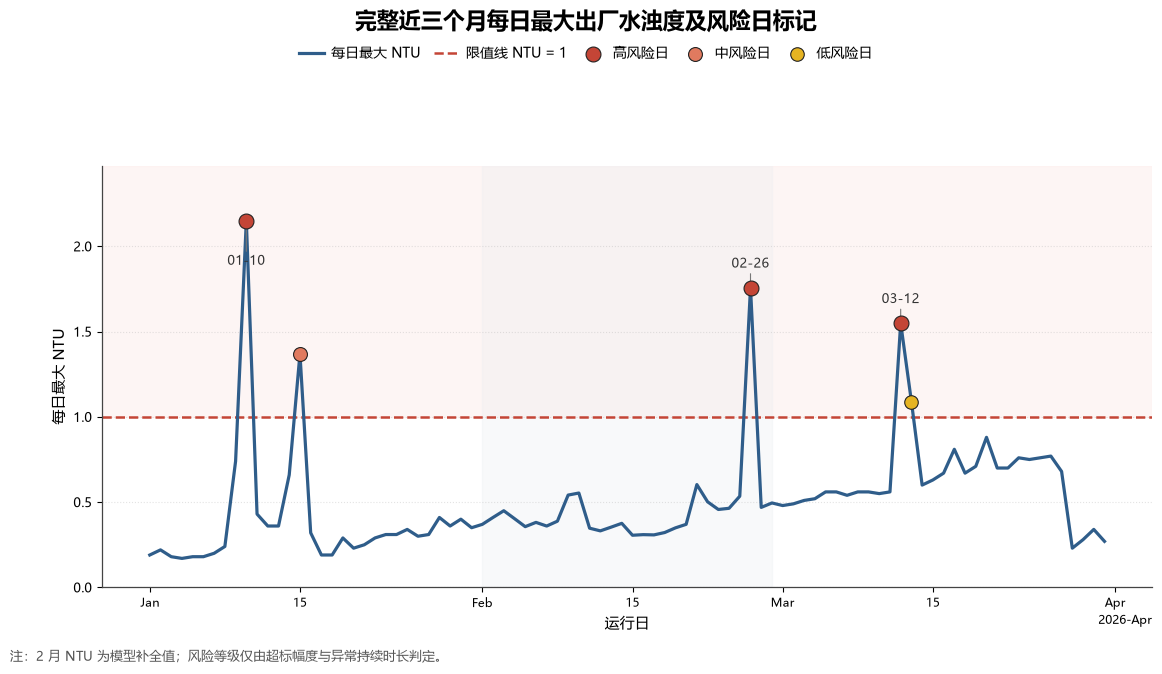

图 A PNG 已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\figures\problem4_A_daily_max_ntu_full_3months.png
图 A PDF 已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\figures\problem4_A_daily_max_ntu_full_3months.pdf


In [27]:
plot_df = daily_risk.copy().sort_values("OP_DATE").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11.8, 6.8))
fig.subplots_adjust(top=0.74, bottom=0.12, left=0.09, right=0.98)

y_upper = max(plot_df["max_NTU"].max() * 1.15, 1.25)
ax.axhspan(NTU_THRESHOLD, y_upper, color="#FDEDEC", alpha=0.55, zorder=0)

line_main, = ax.plot(
    plot_df["OP_DATE"],
    plot_df["max_NTU"],
    color="#2F5D8A",
    linewidth=2.3,
    label="每日最大 NTU",
    zorder=3,
)

line_thr = ax.axhline(
    NTU_THRESHOLD,
    color="#C44536",
    linestyle="--",
    linewidth=1.8,
    label="限值线 NTU = 1",
    zorder=2,
)

# 给 2 月模型补全日加浅灰背景
feb_start = pd.to_datetime("2026-02-01")
feb_end = pd.to_datetime("2026-02-28")
ax.axvspan(feb_start, feb_end, color="#ECEFF1", alpha=0.35, zorder=0, label="2 月模型补全区间")

high_risk_df = plot_df[plot_df["risk_level"] == "HIGH_RISK"].copy()
low_risk_df = plot_df[plot_df["risk_level"] == "LOW_RISK"].copy()
medium_risk_df = plot_df[plot_df["risk_level"] == "MEDIUM_RISK"].copy()

sc_high = None
sc_low = None
sc_medium = None

if len(high_risk_df) > 0:
    sc_high = ax.scatter(
        high_risk_df["OP_DATE"],
        high_risk_df["max_NTU"],
        s=115,
        color=risk_color["HIGH_RISK"],
        edgecolors="#222222",
        linewidths=0.8,
        zorder=5,
        label="高风险日",
    )

if len(medium_risk_df) > 0:
    sc_medium = ax.scatter(
        medium_risk_df["OP_DATE"],
        medium_risk_df["max_NTU"],
        s=100,
        color=risk_color["MEDIUM_RISK"],
        edgecolors="#222222",
        linewidths=0.8,
        zorder=5,
        label="中风险日",
    )

if len(low_risk_df) > 0:
    sc_low = ax.scatter(
        low_risk_df["OP_DATE"],
        low_risk_df["max_NTU"],
        s=95,
        color=risk_color["LOW_RISK"],
        edgecolors="#222222",
        linewidths=0.8,
        zorder=5,
        label="低风险日",
    )

# 只标注高风险日期
for _, row in high_risk_df.iterrows():
    y_val = row["max_NTU"]
    if y_val > y_upper * 0.82:
        offset = (0, -24)
        va = "top"
    else:
        offset = (0, 12)
        va = "bottom"

    ax.annotate(
        row["OP_DATE"].strftime("%m-%d"),
        xy=(row["OP_DATE"], y_val),
        xytext=offset,
        textcoords="offset points",
        ha="center",
        va=va,
        fontsize=9.5,
        color="#333333",
        arrowprops=dict(
            arrowstyle="-",
            color="#777777",
            lw=0.8,
            shrinkA=0,
            shrinkB=5,
        ),
    )

ax.set_xlabel("运行日")
ax.set_ylabel("每日最大 NTU")
ax.set_ylim(0, y_upper)
ax.grid(axis="y", linestyle=":", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

locator = mdates.AutoDateLocator(minticks=5, maxticks=8)
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

fig.suptitle(
    "完整近三个月每日最大出厂水浊度及风险日标记",
    fontsize=16,
    fontweight="bold",
    y=0.97,
)

handles = [line_main, line_thr]
labels = ["每日最大 NTU", "限值线 NTU = 1"]

if sc_high is not None:
    handles.append(sc_high)
    labels.append("高风险日")
if sc_medium is not None:
    handles.append(sc_medium)
    labels.append("中风险日")
if sc_low is not None:
    handles.append(sc_low)
    labels.append("低风险日")

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.935),
    ncol=min(len(handles), 5),
    frameon=False,
    handlelength=1.8,
    handletextpad=0.5,
    columnspacing=1.0,
)

fig.text(
    0.012,
    0.012,
    "注：2 月 NTU 为模型补全值；风险等级仅由超标幅度与异常持续时长判定。",
    fontsize=9,
    color="#555555",
)

fig_path_png = FIG_DIR / "problem4_A_daily_max_ntu_full_3months.png"
fig_path_pdf = FIG_DIR / "problem4_A_daily_max_ntu_full_3months.pdf"

plt.savefig(fig_path_png, dpi=300)
plt.savefig(fig_path_pdf)
plt.show()

print("图 A PNG 已保存：", fig_path_png)
print("图 A PDF 已保存：", fig_path_pdf)


## 17. 图 B：风险等级构成环形图

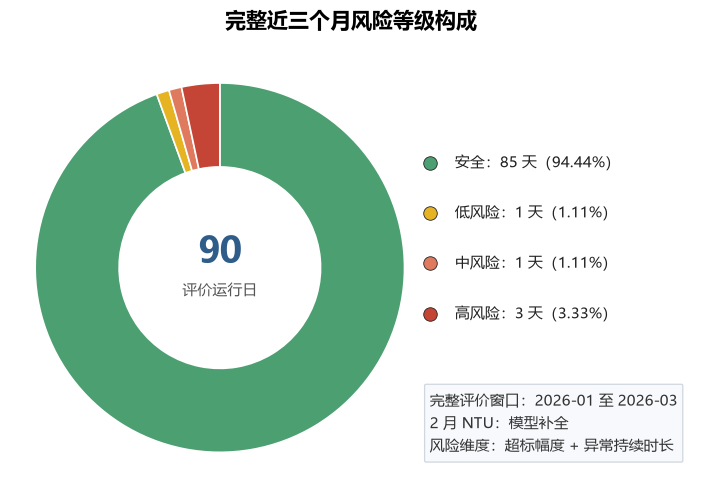

图 B PNG 已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\figures\problem4_B_risk_level_composition_full_3months.png
图 B PDF 已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\figures\problem4_B_risk_level_composition_full_3months.pdf


In [28]:
total_days = int(risk_proportion["days"].sum())
pie_risks = ["SAFE", "LOW_RISK", "MEDIUM_RISK", "HIGH_RISK"]
pie_values = [
    int(risk_proportion.loc[risk_proportion["risk_level"] == r, "days"].iloc[0])
    for r in pie_risks
]
pie_colors = [risk_color[r] for r in pie_risks]

fig, ax = plt.subplots(figsize=(8.8, 5.8))

wedges, _ = ax.pie(
    pie_values,
    labels=None,
    colors=pie_colors,
    startangle=90,
    counterclock=False,
    radius=0.88,
    center=(-0.55, 0),
    wedgeprops=dict(width=0.40, edgecolor="white", linewidth=1.2),
)

ax.text(
    -0.55,
    0.07,
    f"{total_days}",
    ha="center",
    va="center",
    fontsize=26,
    fontweight="bold",
    color="#2F5D8A",
)

ax.text(
    -0.55,
    -0.11,
    "评价运行日",
    ha="center",
    va="center",
    fontsize=11,
    color="#555555",
)

x0 = 0.45
y0 = 0.50
dy = 0.24

for i, risk in enumerate(pie_risks):
    count = pie_values[i]
    ratio = count / total_days * 100 if total_days > 0 else 0
    y = y0 - i * dy

    ax.scatter(
        x0,
        y,
        s=95,
        color=risk_color[risk],
        edgecolor="#222222",
        linewidth=0.6,
    )

    ax.text(
        x0 + 0.12,
        y,
        f"{risk_label_cn[risk]}：{count} 天（{ratio:.2f}%）",
        ha="left",
        va="center",
        fontsize=11,
        color="#222222",
    )

summary_text = (
    f"完整评价窗口：2026-01 至 2026-03\n"
    f"2 月 NTU：模型补全\n"
    f"风险维度：超标幅度 + 异常持续时长"
)

ax.text(
    x0,
    -0.58,
    summary_text,
    ha="left",
    va="top",
    fontsize=10.5,
    color="#333333",
    linespacing=1.45,
    bbox=dict(
        boxstyle="round,pad=0.35,rounding_size=0.10",
        facecolor="#F7F9FC",
        edgecolor="#D0D7DE",
        linewidth=0.9,
    ),
)

ax.set_title("完整近三个月风险等级构成", pad=14, fontsize=15, fontweight="bold")
ax.set_xlim(-1.55, 1.70)
ax.set_ylim(-1.05, 1.05)
ax.set_aspect("equal")
ax.axis("off")

fig_path_png = FIG_DIR / "problem4_B_risk_level_composition_full_3months.png"
fig_path_pdf = FIG_DIR / "problem4_B_risk_level_composition_full_3months.pdf"

plt.savefig(fig_path_png, dpi=300)
plt.savefig(fig_path_pdf)
plt.show()

print("图 B PNG 已保存：", fig_path_png)
print("图 B PDF 已保存：", fig_path_pdf)


## 18. 图 C：2026 年 3 月每日风险分布

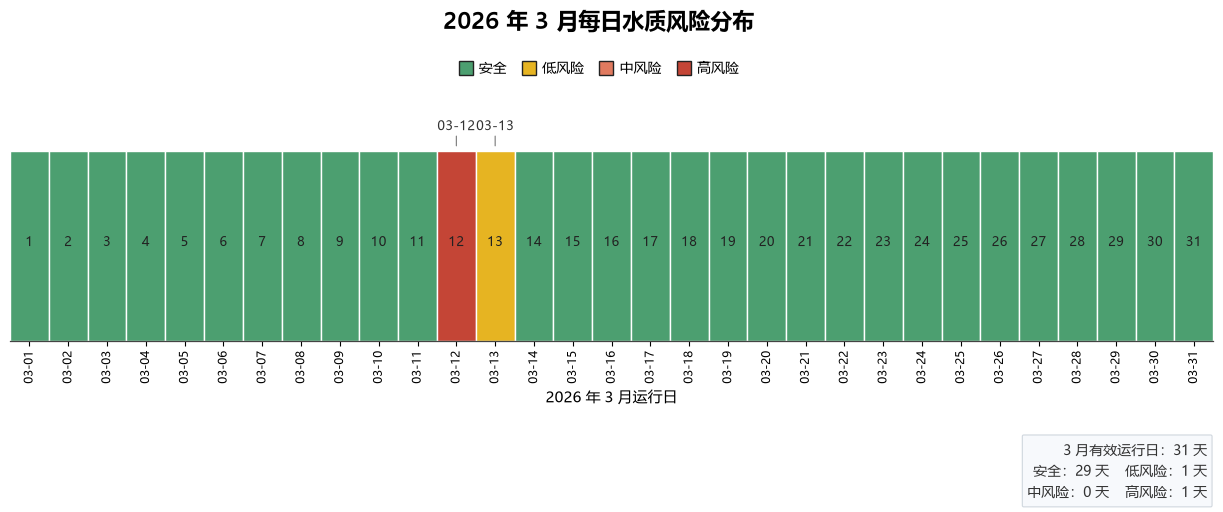

图 C PNG 已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\figures\problem4_C_march_daily_risk_distribution.png
图 C PDF 已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\figures\problem4_C_march_daily_risk_distribution.pdf


In [29]:
march_plot_df = march_daily.copy().sort_values("OP_DATE").reset_index(drop=True)

march_counts = march_plot_df["risk_level"].value_counts()
march_total = len(march_plot_df)

march_safe = int(march_counts.get("SAFE", 0))
march_low = int(march_counts.get("LOW_RISK", 0))
march_med = int(march_counts.get("MEDIUM_RISK", 0))
march_high = int(march_counts.get("HIGH_RISK", 0))

fig, ax = plt.subplots(figsize=(12.8, 4.8))
fig.subplots_adjust(top=0.76, bottom=0.27, left=0.04, right=0.98)

for i, (_, row) in enumerate(march_plot_df.iterrows()):
    color = risk_color.get(row["risk_level"], "#9E9E9E")

    rect = Rectangle(
        (i, 0),
        1,
        1,
        facecolor=color,
        edgecolor="white",
        linewidth=1.0,
    )
    ax.add_patch(rect)

    ax.text(
        i + 0.5,
        0.52,
        str(row["OP_DATE"].day),
        ha="center",
        va="center",
        fontsize=9.3,
        color="#222222",
    )

non_safe_march = march_plot_df[march_plot_df["risk_level"] != "SAFE"].copy()

for _, row in non_safe_march.iterrows():
    idx = march_plot_df.index[march_plot_df["OP_DATE"] == row["OP_DATE"]][0]
    x = idx + 0.5

    ax.annotate(
        row["OP_DATE"].strftime("%m-%d"),
        xy=(x, 1.0),
        xytext=(0, 13),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9.0,
        color="#333333",
        arrowprops=dict(
            arrowstyle="-",
            color="#777777",
            lw=0.8,
            shrinkA=0,
            shrinkB=4,
        ),
    )

ax.set_xlim(0, len(march_plot_df))
ax.set_ylim(0, 1.24)
ax.set_yticks([])

ax.set_xticks(np.arange(len(march_plot_df)) + 0.5)
ax.set_xticklabels(
    [d.strftime("%m-%d") for d in march_plot_df["OP_DATE"]],
    rotation=90,
    fontsize=8.3,
)

ax.set_xlabel("2026 年 3 月运行日", fontsize=11)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

fig.suptitle(
    "2026 年 3 月每日水质风险分布",
    fontsize=16,
    fontweight="bold",
    y=0.96,
)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor=risk_color[level],
        markeredgecolor="#222222",
        markersize=10,
        label=risk_label_cn[level],
    )
    for level in ["SAFE", "LOW_RISK", "MEDIUM_RISK", "HIGH_RISK"]
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.88),
    ncol=4,
    frameon=False,
    fontsize=10,
    handlelength=1.0,
    handletextpad=0.45,
    columnspacing=1.1,
)

summary_text = (
    f"3 月有效运行日：{march_total} 天\n"
    f"安全：{march_safe} 天    低风险：{march_low} 天\n"
    f"中风险：{march_med} 天    高风险：{march_high} 天"
)

ax.text(
    0.995,
    -0.42,
    summary_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    color="#333333",
    linespacing=1.4,
    bbox=dict(
        boxstyle="round,pad=0.35,rounding_size=0.10",
        facecolor="#F7F9FC",
        edgecolor="#D0D7DE",
        linewidth=0.8,
    ),
)

fig_path_png = FIG_DIR / "problem4_C_march_daily_risk_distribution.png"
fig_path_pdf = FIG_DIR / "problem4_C_march_daily_risk_distribution.pdf"

plt.savefig(fig_path_png, dpi=300)
plt.savefig(fig_path_pdf)
plt.show()

print("图 C PNG 已保存：", fig_path_png)
print("图 C PDF 已保存：", fig_path_pdf)


## 19. 输出汇总工作簿

In [30]:
summary_workbook_path = OUTPUT_DIR / "problem4_correct_baseline_summary.xlsx"

with pd.ExcelWriter(summary_workbook_path, engine="openpyxl") as writer:
    missing_month_summary.to_excel(writer, sheet_name="ntu_missing_month", index=False)
    feature_audit.to_excel(writer, sheet_name="imputation_features", index=False)
    impute_results_df.to_excel(writer, sheet_name="imputation_model_results", index=False)
    imputation_source_summary.to_excel(writer, sheet_name="ntu_source_summary", index=False)
    risk_df[["DATETIME", "OP_DATE", "MONTH", "NTU_observed", "NTU_imputed", "NTU_final", "NTU_source", "is_exceed", "excess"]].to_excel(
        writer, sheet_name="point_status", index=False
    )
    daily_indicators.to_excel(writer, sheet_name="daily_indicators", index=False)
    daily_risk.to_excel(writer, sheet_name="daily_classification", index=False)
    risk_proportion.to_excel(writer, sheet_name="risk_proportion", index=False)
    march_daily.to_excel(writer, sheet_name="march_classification", index=False)
    march_summary.to_excel(writer, sheet_name="march_summary", index=False)

print("汇总工作簿已保存：", summary_workbook_path)


汇总工作簿已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_correct_baseline_summary.xlsx


## 20. 最终摘要

In [31]:
final_summary = pd.DataFrame([
    {
        "item": "evaluation_window",
        "value": f"{EVAL_START} to {EVAL_END}",
    },
    {
        "item": "ntu_missing_issue",
        "value": "February 2026 NTU observations are missing and are imputed by model.",
    },
    {
        "item": "ntu_imputation_model",
        "value": best_impute_model_name,
    },
    {
        "item": "risk_dimensions",
        "value": "exceedance magnitude and abnormal duration only",
    },
    {
        "item": "safe_rule",
        "value": "max_NTU <= 1",
    },
    {
        "item": "low_risk_rule",
        "value": "0 < max_excess <= 0.2 and exceed_duration_hours <= 2",
    },
    {
        "item": "high_risk_rule",
        "value": "max_excess > 0.5 or exceed_duration_hours >= 6",
    },
    {
        "item": "medium_risk_rule",
        "value": "exceeded but not low risk or high risk",
    },
    {
        "item": "total_evaluation_days",
        "value": int(risk_proportion["days"].sum()),
    },
])

for _, row in risk_proportion.iterrows():
    final_summary = pd.concat([
        final_summary,
        pd.DataFrame([{
            "item": f"risk_days_{row['risk_level']}",
            "value": f"{int(row['days'])} days ({row['ratio'] * 100:.2f}%)",
        }])
    ], ignore_index=True)

final_summary_path = OUTPUT_DIR / "problem4_correct_baseline_final_summary.xlsx"
final_summary.to_excel(final_summary_path, index=False)

print("最终摘要已保存：", final_summary_path)

print("=" * 80)
print("第四题正确 baseline 已完成。")
print("=" * 80)

print("\n核心输出文件：")
print("1. 2月缺失审计：", missing_summary_path)
print("2. NTU补全模型结果：", impute_results_path)
print("3. 逐点观测/补全数据：", imputation_point_path)
print("4. 点位超标状态：", point_status_path)
print("5. 每日风险指标：", daily_indicators_path)
print("6. 每日风险分类：", daily_risk_path)
print("7. 风险等级占比：", risk_proportion_path)
print("8. 3月每日分类：", march_daily_path)
print("9. 汇总工作簿：", summary_workbook_path)
print("10. 最终摘要：", final_summary_path)
print("11. 图像目录：", FIG_DIR)
print("12. 模型目录：", MODEL_DIR)

display(final_summary)
display(risk_proportion)
display(march_daily[[
    "OP_DATE",
    "mean_NTU",
    "max_NTU",
    "exceed_count",
    "exceed_duration_hours",
    "max_excess",
    "risk_level_cn",
    "main_reason",
]].head(31))


最终摘要已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_correct_baseline_final_summary.xlsx
第四题正确 baseline 已完成。

核心输出文件：
1. 2月缺失审计： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_ntu_missing_month_summary.xlsx
2. NTU补全模型结果： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_ntu_imputation_model_results.xlsx
3. 逐点观测/补全数据： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_ntu_observed_imputed_point_data.xlsx
4. 点位超标状态： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_point_level_status.xlsx
5. 每日风险指标： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_daily_risk_indicators.xlsx
6. 每日风险分类： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_daily_risk_classification.xlsx
7. 风险等级占比： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem4_correct_baseline\problem4_risk_level_proportion.xlsx
8. 3月每日分类： E:\桌面\亚太杯\2026-Asia-P

,item,value
0,evaluation_window,2026-01-01 to 2026-03-31
1,ntu_missing_issue,February 2026 NTU observations are missing and...
2,ntu_imputation_model,Random Forest
3,risk_dimensions,exceedance magnitude and abnormal duration only
4,safe_rule,max_NTU <= 1
5,low_risk_rule,0 < max_excess <= 0.2 and exceed_duration_hour...
6,high_risk_rule,max_excess > 0.5 or exceed_duration_hours >= 6
7,medium_risk_rule,exceeded but not low risk or high risk
8,total_evaluation_days,90
9,risk_days_SAFE,85 days (94.44%)


,risk_level,days,ratio,risk_level_cn
0,SAFE,85,0.944444,安全
1,LOW_RISK,1,0.011111,低风险
2,MEDIUM_RISK,1,0.011111,中风险
3,HIGH_RISK,3,0.033333,高风险
4,UNKNOWN,0,0.000000,未知


,OP_DATE,mean_NTU,max_NTU,exceed_count,exceed_duration_hours,max_excess,risk_level_cn,main_reason
59,2026-03-01,0.452500,0.48,0,0.0,0.00,安全,全天未超标
60,2026-03-02,0.473333,0.49,0,0.0,0.00,安全,全天未超标
61,2026-03-03,0.493333,0.51,0,0.0,0.00,安全,全天未超标
62,2026-03-04,0.501667,0.52,0,0.0,0.00,安全,全天未超标
63,2026-03-05,0.530833,0.56,0,0.0,0.00,安全,全天未超标
64,2026-03-06,0.540000,0.56,0,0.0,0.00,安全,全天未超标
65,2026-03-07,0.525000,0.54,0,0.0,0.00,安全,全天未超标
66,2026-03-08,0.536667,0.56,0,0.0,0.00,安全,全天未超标
67,2026-03-09,0.544167,0.56,0,0.0,0.00,安全,全天未超标
68,2026-03-10,0.539167,0.55,0,0.0,0.00,安全,全天未超标


## 21. 论文中可直接使用的说明

```text
第四问以 2026 年 1 月至 3 月作为近期风险评价窗口。经数据检查发现，2026 年 2 月出厂水浊度 NTU 观测值缺失。为满足题目对近三个月水质状态进行完整评价的要求，本文首先利用同期水厂运行变量建立 NTU 补全模型，对 2 月缺失 NTU 进行模型补全。随后，将 1 月和 3 月实测 NTU 与 2 月模型补全 NTU 合并，形成完整近三个月 NTU 序列。
```

```text
在风险评价阶段，本文严格依据题目要求，仅从超标幅度和异常持续时长两个维度构建风险指标。以 NTU≤1 作为超标判定标准，对每个运行日计算最大 NTU、最大超标幅度和异常持续时长。其中，最大超标幅度反映异常严重程度，异常持续时长反映超标持续性。若当日最大 NTU 不超过 1，则判为安全；若存在超标但最大超标幅度不超过 0.2 且异常持续时长不超过 2 小时，则判为低风险；若最大超标幅度超过 0.5 或异常持续时长不少于 6 小时，则判为高风险；其余存在超标但未达到高风险阈值的日期判为中风险。
```

```text
需要说明的是，2 月风险等级属于基于模型补全 NTU 的估计结果，而 1 月和 3 月风险等级主要基于实际 NTU 观测值计算。
```
